In [38]:
#Reading iOS csv:
import pandas as pd
ios_data = pd.read_pickle("Processed_Data/Full_Datasets/ios_data.pkl")

**iOS Preprocessing**

In [21]:
#Preparing dataset for analysis:
#Select relevant columns for analysis:
y = ios_data['stress']
X = ios_data.drop(columns=['stress', 'uid', 'day'])  # Drop target, ID columns, and date
print("Final feature set columns:", X.columns)
print("Final feature set shape:", X.shape)  

Final feature set columns: Index(['pam', 'phq4-1', 'phq4-2', 'phq4-3', 'phq4-4', 'phq4_resp_mean',
       'phq4_resp_median', 'phq4_score', 'social_level', 'sse3-1',
       ...
       'sleep_heathkit_dur', 'gender', 'race_alaskan native/white',
       'race_american indian/alaska native', 'race_american indian/white',
       'race_asian', 'race_black', 'race_more than one', 'race_other/hispanic',
       'race_white'],
      dtype='str', length=183)
Final feature set shape: (27870, 183)


In [22]:
#Print out all of the features that are empty due to lack of collection for iOS devices:
empty_cols = X.columns[X.isna().all()]
print(empty_cols)

Index(['act_on_foot_ep_0', 'act_on_foot_ep_1', 'act_on_foot_ep_2',
       'act_on_foot_ep_3', 'call_in_duration_ep_0', 'call_in_duration_ep_1',
       'call_in_duration_ep_2', 'call_in_duration_ep_3', 'call_in_num_ep_0',
       'call_in_num_ep_1', 'call_in_num_ep_2', 'call_in_num_ep_3',
       'call_miss_num_ep_0', 'call_miss_num_ep_1', 'call_miss_num_ep_2',
       'call_miss_num_ep_3', 'call_out_duration_ep_0',
       'call_out_duration_ep_1', 'call_out_duration_ep_2',
       'call_out_duration_ep_3', 'call_out_num_ep_0', 'call_out_num_ep_1',
       'call_out_num_ep_2', 'call_out_num_ep_3', 'light_mean_ep_0',
       'light_mean_ep_1', 'light_mean_ep_2', 'light_mean_ep_3',
       'light_std_ep_0', 'light_std_ep_1', 'light_std_ep_2', 'light_std_ep_3',
       'quality_light', 'sms_in_num_ep_0', 'sms_in_num_ep_1',
       'sms_in_num_ep_2', 'sms_in_num_ep_3', 'sms_out_num_ep_0',
       'sms_out_num_ep_1', 'sms_out_num_ep_2', 'sms_out_num_ep_3'],
      dtype='str')


In [23]:
# iOS missing features are all NaN, so we can drop those columns before modeling:
X = X.dropna(axis=1, how='all')

In [24]:
#Splitting data into test and train sets to prevent data leakage:
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold

#Column that identifies groups (participants):
group_col = 'uid'

#80/20 training testing split, with one testing group:
gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=ios_data[group_col]))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = ios_data[group_col].iloc[train_idx]

#Checking stress label distribution to ensure the groups are stratified:
print("Train distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))

Train distribution:
stress
2.0    0.335620
3.0    0.292450
1.0    0.173687
4.0    0.144979
5.0    0.053264
Name: proportion, dtype: float64

Test distribution:
stress
2.0    0.359751
3.0    0.285915
1.0    0.171950
4.0    0.142055
5.0    0.040329
Name: proportion, dtype: float64


In [25]:
#Checking to see how many unique stress levels each participant has in the merged dataset:
ios_data.groupby("uid")["stress"].nunique().value_counts()

stress
5    131
4     57
3      6
1      2
Name: count, dtype: int64

In [26]:
#Splitting training set into groups with StratifiedGroupKFold:
gkf = StratifiedGroupKFold(n_splits=5)

**Feature Selection**

In [27]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np

#Cross-validation loop for ElasticNet regression with median imputation and standardization:

mae_scores = []

for train_idx, val_idx in gkf.split(X_train, y_train, groups=groups_train):
    
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    #Pipeline with median imputation and ElasticNet regression:
    EN_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("elasticnet", ElasticNet(
            alpha=0.1,
            l1_ratio=0.3,
            max_iter=5000,
            random_state=42)
        )
    ])
    
    EN_model.fit(X_tr, y_tr)
    
    preds = EN_model.predict(X_val)
    mae_scores.append(mean_absolute_error(y_val, preds))

print("ElasticNet CV MAE:", np.mean(mae_scores))
    

ElasticNet CV MAE: 0.7045940289197501


In [28]:
#Extracting feature importance from the ElasticNet model:
elastic = EN_model.named_steps["elasticnet"]
coefs = elastic.coef_
feature_names = X_train.columns

#Create a dataframe to display feature names and their corresponding coefficients:
EN_importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs
})

EN_importance["abs_coef"] = EN_importance["coefficient"].abs()
EN_importance = EN_importance.sort_values(by="abs_coef", ascending=False)

print(EN_importance.head(20))

                          feature  coefficient  abs_coef
9                          sse3-1     0.210647  0.210647
1                          phq4-1     0.136034  0.136034
12                         sse3-4    -0.121964  0.121964
2                          phq4-2     0.098698  0.098698
7                      phq4_score     0.086685  0.086685
11                         sse3-3    -0.080396  0.080396
29                 act_still_ep_0     0.056999  0.056999
100                 loc_study_dur     0.053269  0.053269
4                          phq4-4     0.039400  0.039400
140           race_other/hispanic     0.033823  0.033823
130               unlock_num_ep_2     0.025821  0.025821
71   loc_max_dis_from_campus_ep_0    -0.022475  0.022475
84              loc_self_dorm_dur     0.021809  0.021809
31                 act_still_ep_2     0.019758  0.019758
119                 quality_audio    -0.019278  0.019278
14               sse3_resp_median    -0.016489  0.016489
122                     sleep_e

In [29]:
#List of non-zero coefficients (indicate features that contribute to the model's predictions):
selected_features = EN_importance[EN_importance["coefficient"] != 0]
print(selected_features)

                          feature  coefficient  abs_coef
9                          sse3-1     0.210647  0.210647
1                          phq4-1     0.136034  0.136034
12                         sse3-4    -0.121964  0.121964
2                          phq4-2     0.098698  0.098698
7                      phq4_score     0.086685  0.086685
11                         sse3-3    -0.080396  0.080396
29                 act_still_ep_0     0.056999  0.056999
100                 loc_study_dur     0.053269  0.053269
4                          phq4-4     0.039400  0.039400
140           race_other/hispanic     0.033823  0.033823
130               unlock_num_ep_2     0.025821  0.025821
71   loc_max_dis_from_campus_ep_0    -0.022475  0.022475
84              loc_self_dorm_dur     0.021809  0.021809
31                 act_still_ep_2     0.019758  0.019758
119                 quality_audio    -0.019278  0.019278
14               sse3_resp_median    -0.016489  0.016489
122                     sleep_e

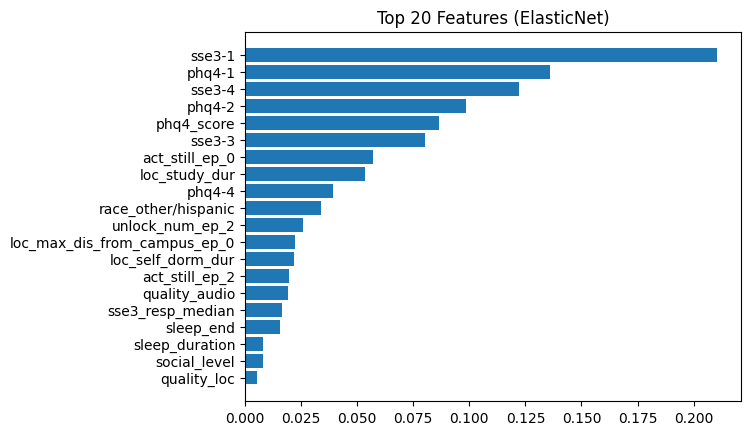

In [30]:
import matplotlib.pyplot as plt

#Visualize the top 20 most important features based on absolute coefficient values:
top = EN_importance.head(20)
plt.figure()
plt.barh(top["feature"], top["abs_coef"])
plt.gca().invert_yaxis()
plt.title("Top 20 Features (ElasticNet)")
plt.show()

In [31]:
#XGBoost regression with median imputation and standardization:
from xgboost import XGBRegressor

mae_scores_xgb = []

for train_idx, val_idx in gkf.split(X_train, y_train, groups=groups_train):
    
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    XGBR_model = XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    
    XGBR_model.fit(X_tr.values, y_tr.values)
    
    preds = XGBR_model.predict(X_val.values)
    mae_scores_xgb.append(mean_absolute_error(y_val, preds))

print("XGBoost CV MAE:", np.mean(mae_scores_xgb))

XGBoost CV MAE: 0.6622889754844904


In [32]:
#Final XGBoost model trained on the entire training set for feature importance:
final_XGBR_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

final_XGBR_model.fit(X_train.values, y_train.values)

#Feature importance from XGBoost model:
xgb_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": XGBR_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(by="importance", ascending=False)

xgb_importance.head(20)

,feature,importance
2,phq4-2,0.210044
7,phq4_score,0.120702
12,sse3-4,0.048386
1,phq4-1,0.047343
9,sse3-1,0.045008
11,sse3-3,0.019587
0,pam,0.013765
17,act_in_vehicle_ep_0,0.013420
100,loc_study_dur,0.012807
19,act_in_vehicle_ep_2,0.010905


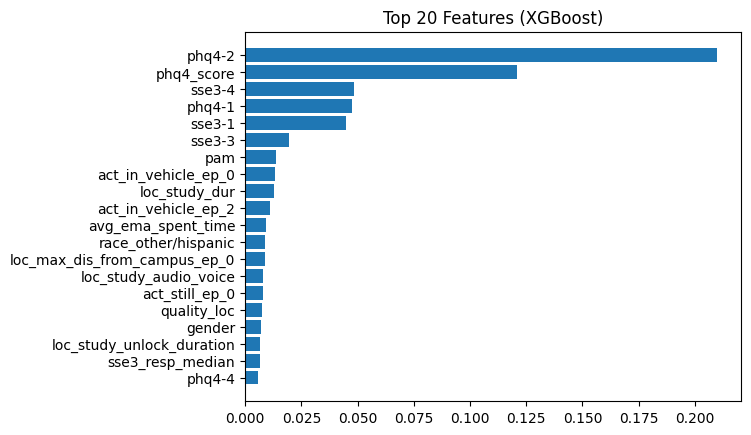

In [33]:
#Visualize the top 20 most important features from the XGBoost model:
top = xgb_importance.head(20)

plt.figure()
plt.barh(top["feature"], top["importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Features (XGBoost)")
plt.show()

In [34]:
#Merge results from ElasticNet and XGBoost to see which features are important in both models:
iOS_merged_importance = pd.merge(
    EN_importance[["feature", "coefficient"]],
    xgb_importance[["feature", "importance"]],
    on="feature",
    how="inner"
)

#Normalize importance values for better comparison:
iOS_merged_importance["coef_norm"] = iOS_merged_importance["coefficient"].abs() / iOS_merged_importance["coefficient"].abs().max()
iOS_merged_importance["xgb_norm"] = iOS_merged_importance["importance"] / iOS_merged_importance["importance"].max()

#Create a combined importance score by averaging the normalized values from both models:
iOS_merged_importance["combined_score"] = (iOS_merged_importance["coef_norm"] + iOS_merged_importance["xgb_norm"]) / 2

#Keep only relevant columns and sort by combined score:
iOS_merged_importance = iOS_merged_importance[["feature", "coef_norm", "xgb_norm", "combined_score"]]
iOS_merged_importance = iOS_merged_importance.sort_values(by="combined_score", ascending=False)

print(iOS_merged_importance.head(20))

                         feature  coef_norm  xgb_norm  combined_score
3                         phq4-2   0.468549  1.000000        0.734275
0                         sse3-1   1.000000  0.214279        0.607139
4                     phq4_score   0.411520  0.574651        0.493086
1                         phq4-1   0.645792  0.225394        0.435593
2                         sse3-4   0.578998  0.230363        0.404681
5                         sse3-3   0.381662  0.093253        0.237458
7                  loc_study_dur   0.252884  0.060971        0.156928
6                 act_still_ep_0   0.270589  0.037296        0.153942
8                         phq4-4   0.187044  0.028249        0.107647
9            race_other/hispanic   0.160566  0.042215        0.101391
11  loc_max_dis_from_campus_ep_0   0.106694  0.041532        0.074113
10               unlock_num_ep_2   0.122581  0.019140        0.070860
12             loc_self_dorm_dur   0.103533  0.014678        0.059106
14                 q

In [35]:
#Selecting features that have a combined importance score above a threshold of 0.02:
iOS_selected_features = iOS_merged_importance[
    iOS_merged_importance["combined_score"] > 0.01
]["feature"]

print("Number of selected features:", len(iOS_selected_features))

Number of selected features: 49


In [36]:
#Reducing the feature set to only the selected features for modeling:
#Printing shape of X after feature selection to confirm the number of features has been reduced:
X = X[iOS_selected_features]
print("Shape of X after feature selection:", X.shape)

Shape of X after feature selection: (27870, 49)


In [37]:
#Create a new dataframe with the selected features for future modeling:
X_selected = X[iOS_selected_features]
X_selected.to_pickle("Processed_Data/iOS_SelectedFeatures.pkl")